# LSEG cash-flow-distance reliability gate

**Objective.** Validate the frozen human-coding worksheets and evaluate the
predeclared inter-coder reliability gate when both are complete. This notebook
uses the local Reuters text only for identity validation; it displays and
persists aggregate progress/reliability evidence only. It never loads returns,
positions, or sentiment scores.

## Frozen decision rule

The construct passes only if quadratic-weighted Cohen's kappa is at least
0.60, its 95% event-bootstrap lower bound is at least 0.40, adjacent agreement
is at least 0.80, and at least 48 of the 60 pairs are jointly numeric. `NA` is
excluded from ordinal kappa; exact and adjacent agreement use all 60 events.
The bootstrap has 9,999 event resamples and seed `20260819`. Undefined kappa
replicates are omitted. These rules were frozen before coding.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "final_experiments").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.cash_flow_audit import (  # noqa: E402
    MIN_JOINT_NUMERIC,
    RELIABILITY_BOOTSTRAP_REPLICATIONS,
    RELIABILITY_SEED,
    evaluate_cash_flow_reliability,
    load_cash_flow_audit_state,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402

PACK = ROOT / "final_experiments/outputs/16_lseg_cash_flow_distance_audit"
OUTPUT = ROOT / "final_experiments/outputs/62_lseg_cash_flow_distance_reliability_gate"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Validate worksheet identity and completion

The loader verifies the private sampling key, row/ID contracts, and immutable
ID/headline/body hashes. Coding columns may change; sampled stories may not.
No story text is displayed. Partial or invalid rows fail closed.

In [2]:
state = load_cash_flow_audit_state(PACK)
progress = pd.DataFrame(
    [
        {"coder": "A", **state["coder_a_status"]},
        {"coder": "B", **state["coder_b_status"]},
    ]
).set_index("coder")
display(progress[["rows", "complete_rows", "partial_rows", "unstarted_rows", "is_complete"]])
print("ready for reliability:", state["ready_for_reliability"])

,rows,complete_rows,partial_rows,unstarted_rows,is_complete
coder,,,,,
A,200,0,0,200,False
B,60,0,0,60,False


ready for reliability: False


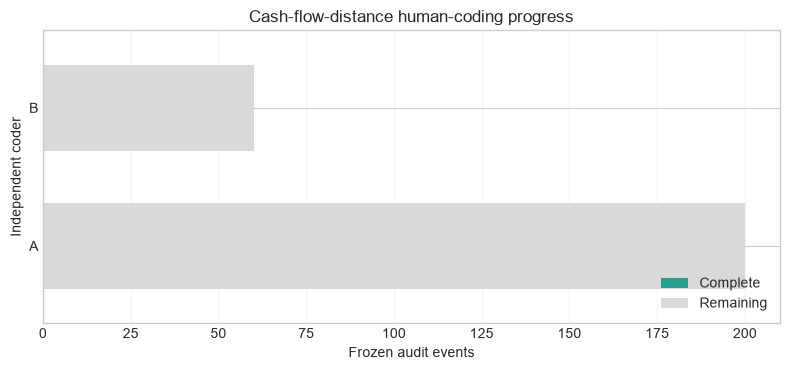

In [3]:
plot_progress = progress[["complete_rows"]].copy()
plot_progress["remaining_rows"] = progress["rows"] - progress["complete_rows"]
ax = plot_progress.plot.barh(
    stacked=True, figsize=(8, 3.8), color=["#2A9D8F", "#D9D9D9"], width=0.62
)
ax.set_xlabel("Frozen audit events")
ax.set_ylabel("Independent coder")
ax.set_title("Cash-flow-distance human-coding progress")
ax.legend(["Complete", "Remaining"], frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT / "coding_progress.png", dpi=160, bbox_inches="tight")
plt.show()

## Reliability assessment

Reliability is not estimated from incomplete sheets. Once both are complete,
this cell reports the frozen metrics, full 5×5 confusion matrix, and bootstrap
distribution without opening the private proxy strata or any market outcome.

In [4]:
metrics = None
confusion = None
bootstrap = None
if state["ready_for_reliability"]:
    metrics, confusion, bootstrap = evaluate_cash_flow_reliability(
        state["coder_a"],
        state["coder_b"],
        replications=RELIABILITY_BOOTSTRAP_REPLICATIONS,
        seed=RELIABILITY_SEED,
    )
    display(pd.DataFrame([metrics]))
    display(confusion)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].hist(bootstrap, bins=30, color="#4C78A8", alpha=0.85)
    axes[0].axvline(0.40, color="#D62728", linestyle="--", label="lower-bound gate")
    axes[0].set_title("Event-bootstrap weighted kappa")
    axes[0].set_xlabel("Quadratic-weighted kappa")
    axes[0].set_ylabel("Resamples")
    axes[0].legend(frameon=False)
    image = axes[1].imshow(confusion.to_numpy(), cmap="Blues")
    axes[1].set_xticks(range(len(confusion.columns)), confusion.columns)
    axes[1].set_yticks(range(len(confusion.index)), confusion.index)
    axes[1].set_xlabel("Coder B")
    axes[1].set_ylabel("Coder A")
    axes[1].set_title("Double-code confusion matrix")
    for row, column in np.ndindex(confusion.shape):
        axes[1].text(column, row, int(confusion.iloc[row, column]), ha="center", va="center")
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(OUTPUT / "reliability_gate.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    display(Markdown("**WAITING_FOR_HUMAN_LABELS.** Reliability was not estimated."))

**WAITING_FOR_HUMAN_LABELS.** Reliability was not estimated.

## Aggregate-only hand-off

The output manifest is authoritative. A passing reliability gate validates
coding consistency, not predictive value, and does not promote a strategy. A
failed gate requires a revised codebook and a fresh blinded sample.

In [5]:
status = (
    "reliability_passed"
    if metrics is not None and metrics["gate_pass"]
    else "reliability_failed"
    if metrics is not None
    else "waiting_for_human_labels"
)
progress.reset_index().to_csv(OUTPUT / "coding_status.csv", index=False)
current_files = ["coding_status.csv", "coding_progress.png"]
if metrics is not None:
    pd.DataFrame([metrics]).to_csv(OUTPUT / "reliability_metrics.csv", index=False)
    confusion.to_csv(OUTPUT / "confusion_matrix.csv")
    current_files.extend(["reliability_metrics.csv", "confusion_matrix.csv", "reliability_gate.png"])
else:
    for stale in ("reliability_metrics.csv", "confusion_matrix.csv", "reliability_gate.png"):
        (OUTPUT / stale).unlink(missing_ok=True)

result_manifest = {
    "status": status,
    "estimand": "inter-coder reliability of the frozen 0-3 cash-flow-distance construct",
    "input_pack_manifest_sha256": sha256_file(PACK / "manifest.json"),
    "gate": {
        "minimum_quadratic_weighted_kappa": 0.60,
        "minimum_kappa_ci_lower_95": 0.40,
        "minimum_adjacent_agreement": 0.80,
        "minimum_joint_numeric_rows": MIN_JOINT_NUMERIC,
        "bootstrap_replications": RELIABILITY_BOOTSTRAP_REPLICATIONS,
        "bootstrap_seed": RELIABILITY_SEED,
    },
    "coding_progress": progress[["rows", "complete_rows", "partial_rows", "unstarted_rows"]].to_dict(orient="index"),
    "claim_boundary": [
        "no returns, positions, or sentiment scores loaded",
        "machine proxy is not treated as validation",
        "reliability alone cannot promote a trading strategy",
    ],
    "files": {name: sha256_file(OUTPUT / name) for name in current_files},
}
(OUTPUT / "manifest.json").write_text(
    json.dumps(result_manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
print(json.dumps({"status": status, "coding_progress": result_manifest["coding_progress"]}, indent=2))

{
  "status": "waiting_for_human_labels",
  "coding_progress": {
    "A": {
      "rows": 200,
      "complete_rows": 0,
      "partial_rows": 0,
      "unstarted_rows": 200
    },
    "B": {
      "rows": 60,
      "complete_rows": 0,
      "partial_rows": 0,
      "unstarted_rows": 60
    }
  }
}


**Current interpretation.** Until both blinded worksheets are complete, the
cash-flow-distance construct remains unvalidated and no human-label return
experiment is authorised.